In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Users/kunja/Downloads/funnel_events_sample.csv")

In [3]:
df.head()

,user_id,step,timestamp
0,U045,visited_site,2026-07-20 03:40:00
1,U014,signup_started,2026-07-20 04:24:00
2,U007,details_filled,2026-07-20 04:11:00
3,U108,signup_started,2026-07-20 04:23:00
4,U134,signup_started,2026-07-20 03:52:00


In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [5]:
steps = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

In [6]:
counts = []

for step in steps:
    counts.append(df[df["step"] == step]["user_id"].nunique())

result = pd.DataFrame({
    "Stage": steps,
    "Users": counts
})

In [7]:
result["Previous Stage Users"] = result["Users"].shift(1)
result["Conversion Rate (%)"] = (
    result["Users"] /
    result["Previous Stage Users"] * 100
).round(2)

result.loc[0, "Conversion Rate (%)"] = 100

In [8]:
result["Drop-off Users"] = (
    result["Previous Stage Users"] - result["Users"]
)

result["Drop-off (%)"] = (
    result["Drop-off Users"] /
    result["Previous Stage Users"] * 100
).round(2)

print(result)

                Stage  Users  Previous Stage Users  Conversion Rate (%)  \
0        visited_site    200                   NaN               100.00   
1      signup_started    150                 200.0                75.00   
2      details_filled     96                 150.0                64.00   
3      email_verified     52                  96.0                54.17   
4  purchase_completed     44                  52.0                84.62   

   Drop-off Users  Drop-off (%)  
0             NaN           NaN  
1            50.0         25.00  
2            54.0         36.00  
3            44.0         45.83  
4             8.0         15.38  


In [9]:
largest = result["Drop-off Users"].idxmax()

print("\nBiggest Drop-off Stage")
print(
    f"{result.loc[largest-1,'Stage']} -> {result.loc[largest,'Stage']}"
)
print(f"Users Lost: {int(result.loc[largest,'Drop-off Users'])}")


Biggest Drop-off Stage
signup_started -> details_filled
Users Lost: 54


In [10]:
print("\nAverage Time Between Consecutive Stages")

for i in range(len(steps)-1):

    s1 = steps[i]
    s2 = steps[i+1]

    t1 = (
        df[df["step"] == s1]
        .groupby("user_id")["timestamp"]
        .min()
    )

    t2 = (
        df[df["step"] == s2]
        .groupby("user_id")["timestamp"]
        .min()
    )

    merged = pd.concat([t1, t2], axis=1)
    merged.columns = ["t1", "t2"]
    merged = merged.dropna()

    if len(merged) > 0:
        avg = (
            (merged["t2"] - merged["t1"])
            .dt.total_seconds()
            .mean() / 60
        )
        print(f"{s1} -> {s2}: {avg:.2f} minutes")
    else:
        print(f"{s1} -> {s2}: No matching users")


Average Time Between Consecutive Stages
visited_site -> signup_started: 13.85 minutes
signup_started -> details_filled: 17.09 minutes
details_filled -> email_verified: No matching users
email_verified -> purchase_completed: No matching users


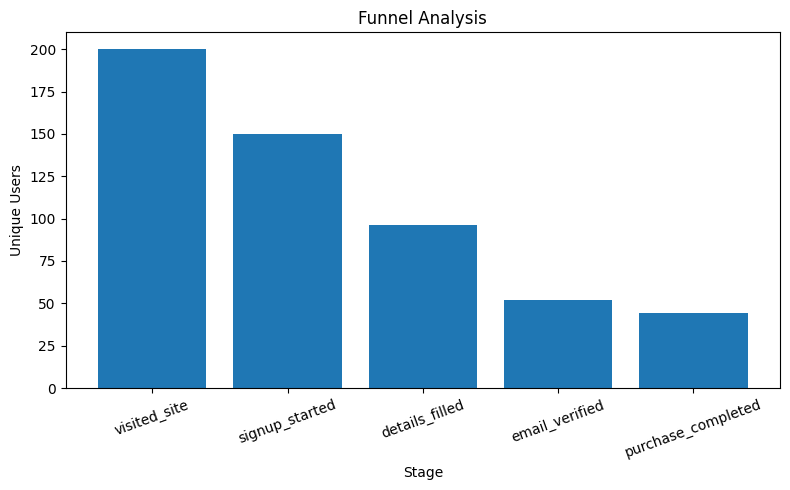

In [11]:
plt.figure(figsize=(8,5))
plt.bar(result["Stage"], result["Users"])
plt.title("Funnel Analysis")
plt.xlabel("Stage")
plt.ylabel("Unique Users")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()